<a href="https://colab.research.google.com/github/fablan-code/portfolio/blob/main/M%C3%A9todolog%C3%ADas_Avanzadas_de_Aprendizaje_Autom%C3%A1tico_TP_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

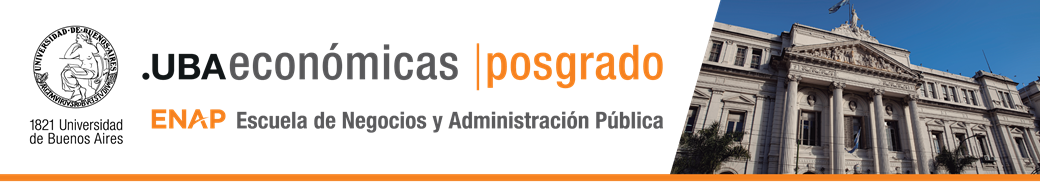

# **Metodologías Avanzados de Aprendizaje Automático** - TP1

**Docentes: Roberto Abalde, Mónica Cantoni**

**Alumno: Facundo Matías Blanco**

In [ ]:
import pandas as pd
import sklearn as sk
from sklearn import model_selection
from sklearn import neural_network
from sklearn import metrics
import numpy as np
from tensorflow import keras
import matplotlib.pyplot as plt
SEED = 42
np.random.seed(SEED)
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
from sklearn.ensemble import GradientBoostingRegressor
from scipy.stats import uniform

# Dataset 1 - Regresión

## Lectura y tratamiento de datos

In [ ]:
df_autos=pd.read_csv("/content/car details v4.csv")
print (df_autos.shape)
df_autos.head(5)

(2059, 20)


,Make,Model,Price,Year,Kilometer,Fuel Type,Transmission,Location,Color,Owner,Seller Type,Engine,Max Power,Max Torque,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
0,Honda,Amaze 1.2 VX i-VTEC,505000,2017,87150,Petrol,Manual,Pune,Grey,First,Corporate,1198 cc,87 bhp @ 6000 rpm,109 Nm @ 4500 rpm,FWD,3990.0,1680.0,1505.0,5.0,35.0
1,Maruti Suzuki,Swift DZire VDI,450000,2014,75000,Diesel,Manual,Ludhiana,White,Second,Individual,1248 cc,74 bhp @ 4000 rpm,190 Nm @ 2000 rpm,FWD,3995.0,1695.0,1555.0,5.0,42.0
2,Hyundai,i10 Magna 1.2 Kappa2,220000,2011,67000,Petrol,Manual,Lucknow,Maroon,First,Individual,1197 cc,79 bhp @ 6000 rpm,112.7619 Nm @ 4000 rpm,FWD,3585.0,1595.0,1550.0,5.0,35.0
3,Toyota,Glanza G,799000,2019,37500,Petrol,Manual,Mangalore,Red,First,Individual,1197 cc,82 bhp @ 6000 rpm,113 Nm @ 4200 rpm,FWD,3995.0,1745.0,1510.0,5.0,37.0
4,Toyota,Innova 2.4 VX 7 STR [2016-2020],1950000,2018,69000,Diesel,Manual,Mumbai,Grey,First,Individual,2393 cc,148 bhp @ 3400 rpm,343 Nm @ 1400 rpm,RWD,4735.0,1830.0,1795.0,7.0,55.0


In [ ]:
#EDA
df_autos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2059 entries, 0 to 2058
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Make                2059 non-null   object 
 1   Model               2059 non-null   object 
 2   Price               2059 non-null   int64  
 3   Year                2059 non-null   int64  
 4   Kilometer           2059 non-null   int64  
 5   Fuel Type           2059 non-null   object 
 6   Transmission        2059 non-null   object 
 7   Location            2059 non-null   object 
 8   Color               2059 non-null   object 
 9   Owner               2059 non-null   object 
 10  Seller Type         2059 non-null   object 
 11  Engine              1979 non-null   object 
 12  Max Power           1979 non-null   object 
 13  Max Torque          1979 non-null   object 
 14  Drivetrain          1923 non-null   object 
 15  Length              1995 non-null   float64
 16  Width 

In [ ]:
# EDA valores nulos
nulls = df_autos.isnull().sum()
nulls_pct = (nulls / len(df_autos) * 100).round(1)
pd.DataFrame({'nulos': nulls, '%': nulls_pct})[nulls > 0]

,nulos,%
Engine,80,3.9
Max Power,80,3.9
Max Torque,80,3.9
Drivetrain,136,6.6
Length,64,3.1
Width,64,3.1
Height,64,3.1
Seating Capacity,64,3.1
Fuel Tank Capacity,113,5.5


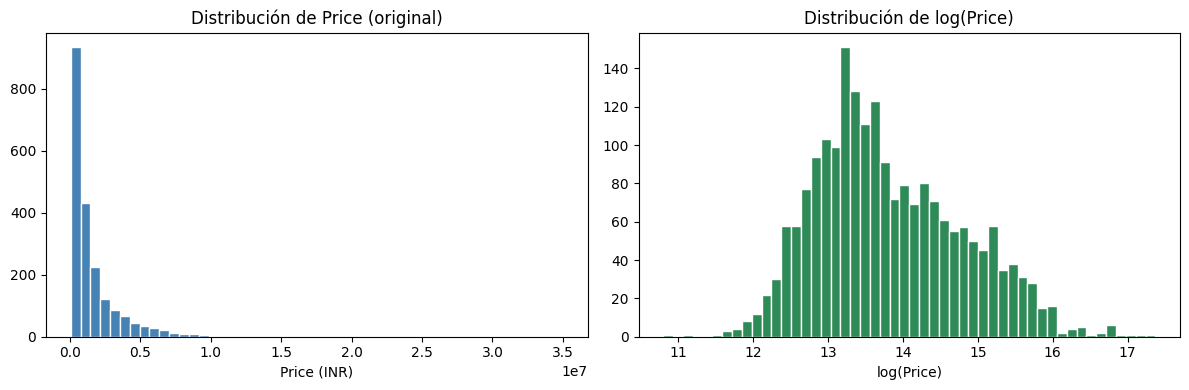

Skewness original: 4.965
Skewness log:      0.486


In [ ]:
#EDA — distribución del target
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_autos['Price'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de Price (original)')
axes[0].set_xlabel('Price (INR)')

axes[1].hist(np.log1p(df_autos['Price']), bins=50, color='seagreen', edgecolor='white')
axes[1].set_title('Distribución de log(Price)')
axes[1].set_xlabel('log(Price)')

plt.tight_layout()
plt.show()

print(f"Skewness original: {df_autos['Price'].skew():.3f}")
print(f"Skewness log:      {np.log1p(df_autos['Price']).skew():.3f}")

In [ ]:
#Modelos
print("Modelos")
print(df_autos['Model'].value_counts())

Modelos
Model
X1 sDrive20d xLine                 15
Swift DZire VDI                    14
Fortuner 2.8 4x2 AT [2016-2020]    13
City V                             13
Swift VXi [2014-2017]              12
                                   ..
Alto 800 Std                        1
Innova 2.0 G1 BS-IV                 1
GLA 200 d Style                     1
Fiesta Titanium Diesel              1
Wagon R LXi 1.0 CNG                 1
Name: count, Length: 1050, dtype: int64


In [ ]:
# EDA variables categóricas
for col in ['Fuel Type', 'Transmission', 'Owner', 'Seller Type', 'Drivetrain']:
    print(f"\n{col}:\n{df_autos[col].value_counts().to_string()}")


Fuel Type:
Fuel Type
Diesel          1049
Petrol           942
CNG               50
Electric           7
LPG                5
Hybrid             3
CNG + CNG          1
Petrol + CNG       1
Petrol + LPG       1

Transmission:
Transmission
Manual       1133
Automatic     926

Owner:
Owner
First               1619
Second               373
Third                 42
UnRegistered Car      21
Fourth                 3
4 or More              1

Seller Type:
Seller Type
Individual                 1997
Corporate                    57
Commercial Registration       5

Drivetrain:
Drivetrain
FWD    1330
RWD     321
AWD     272


In [ ]:
#verificación de la columna 'Seller Type'
print("Distribución por Tipo de Vendedor:")
print(df_autos['Seller Type'].value_counts())
print("Porcentaje de Tipo de Vendedor:")
print(df_autos['Seller Type'].value_counts(normalize=True))

Distribución por Tipo de Vendedor:
Seller Type
Individual                 1997
Corporate                    57
Commercial Registration       5
Name: count, dtype: int64
Porcentaje de Tipo de Vendedor:
Seller Type
Individual                 0.969888
Corporate                  0.027683
Commercial Registration    0.002428
Name: proportion, dtype: float64


In [ ]:
#Colores
print("Colores")
print(df_autos['Color'].value_counts())

Colores
Color
White     802
Silver    285
Grey      220
Blue      190
Black     163
Red       154
Brown      82
Maroon     37
Gold       30
Bronze     28
Green      17
Orange     16
Others     12
Yellow      9
Beige       8
Purple      5
Pink        1
Name: count, dtype: int64


In [ ]:
#verificación Owner
print("Distribución por Dueño:")
print(df_autos['Owner'].value_counts())
#porcentaje
print("Porcentaje de Dueño:")
print(df_autos['Owner'].value_counts(normalize=True))

Distribución por Dueño:
Owner
First               1619
Second               373
Third                 42
UnRegistered Car      21
Fourth                 3
4 or More              1
Name: count, dtype: int64
Porcentaje de Dueño:
Owner
First               0.786304
Second              0.181156
Third               0.020398
UnRegistered Car    0.010199
Fourth              0.001457
4 or More           0.000486
Name: proportion, dtype: float64


In [ ]:
#Drivetrain
print("Drivetrain")
print(df_autos['Drivetrain'].value_counts())
#nans de drivetrain
print("Nans de drivetrain")
print(df_autos['Drivetrain'].isna().sum())


Drivetrain
Drivetrain
FWD    1330
RWD     321
AWD     272
Name: count, dtype: int64
Nans de drivetrain
136


In [ ]:
#Verificación Localidad
print("Localidad")
print(df_autos['Location'].value_counts())

Localidad
Location
Mumbai              342
Delhi               307
Pune                144
Bangalore           132
Hyderabad           116
                   ... 
Valsad                1
Rohtak                1
Faizabad              1
Pimpri-Chinchwad      1
Siliguri              1
Name: count, Length: 77, dtype: int64


##Preprocesamiento de datos

In [ ]:
#Preprocesamiento de datos
df = df_autos.copy()

# 1. Drop columnas sin poder predictivo o alta cardinalidad
#    - Model: 1050 valores únicos → no generaliza
#    - Location: 77 ciudades → proxy ruidoso del precio
#    - Color: no determinante del precio de un usado
df.drop(columns=['Model', 'Location', 'Color'], inplace=True)

In [ ]:
# 2. Extraer valores numéricos de columnas de texto
#    Engine viene como "1197 cc", Max Power como "87 bhp @ 6000 rpm", etc.
df['Engine_cc'] = df['Engine'].str.extract(r'(\d+\.?\d*)').astype(float)
df['Power_bhp'] = df['Max Power'].str.extract(r'(\d+\.?\d*)').astype(float)
df['Torque_Nm'] = df['Max Torque'].str.extract(r'(\d+\.?\d*)').astype(float)
df.drop(columns=['Engine', 'Max Power', 'Max Torque'], inplace=True)

In [ ]:
# 3. Encoding ordinal para Owner (tiene orden natural)
owner_map = {
    'UnRegistered Car': 0,
    'First': 1,
    'Second': 2,
    'Third': 3,
    'Fourth': 4,
    '4 or More': 5
}
df['Owner'] = df['Owner'].map(owner_map)

In [ ]:
# Agrupar categorías poco frecuentes en Fuel Type
fuel_principales = ['Diesel', 'Petrol', 'CNG', 'Electric']
df['Fuel Type'] = df['Fuel Type'].apply(lambda x: x if x in fuel_principales else 'Other')

In [ ]:
# One-hot encoding para variables nominales
df = pd.get_dummies(df, columns=['Make', 'Fuel Type', 'Transmission', 'Seller Type', 'Drivetrain'])

In [ ]:
# Convertir booleanos a int (necesario para normalización)
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

In [ ]:
# Imputar nulos con mediana (distribución sesgada → mediana > media)
for col in df.select_dtypes(include='number').columns:
    df[col] = df[col].fillna(df[col].median())

In [ ]:
# Transformación log del target (reduce skewness de 4.96 a 0.49)
df['Price'] = np.log1p(df['Price'])

In [ ]:
# 8. Normalización min-max
df = (df - df.min()) / (df.max() - df.min())

print(f"Shape final: {df.shape}")
print(f"Nulos restantes: {df.isnull().sum().sum()}")
df.head()

Shape final: (2059, 58)
Nulos restantes: 0


,Price,Year,Kilometer,Owner,Length,Width,Height,Seating Capacity,Fuel Tank Capacity,Engine_cc,...,Fuel Type_Other,Fuel Type_Petrol,Transmission_Automatic,Transmission_Manual,Seller Type_Commercial Registration,Seller Type_Corporate,Seller Type_Individual,Drivetrain_AWD,Drivetrain_FWD,Drivetrain_RWD
0,0.354988,0.852941,0.043575,0.2,0.360729,0.275168,0.409639,0.500000,0.222222,0.096180,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
1,0.337440,0.764706,0.037500,0.4,0.362753,0.295302,0.469880,0.500000,0.300000,0.104558,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
2,0.228539,0.676471,0.033500,0.2,0.196761,0.161074,0.463855,0.500000,0.222222,0.096012,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
3,0.424807,0.911765,0.018750,0.2,0.362753,0.362416,0.415663,0.500000,0.244444,0.096012,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
4,0.560584,0.882353,0.034500,0.2,0.662348,0.476510,0.759036,0.833333,0.444444,0.296414,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0


##Modelado

In [ ]:
# Train/Test split
X = df.drop(columns=['Price'])
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")

X_train: (1647, 57) | X_test: (412, 57)


In [ ]:
#Keras
keras.utils.set_random_seed(SEED)

model_nn = keras.Sequential([
    keras.layers.Input(shape=(X_train.shape[1],)),

    # Capa oculta 1
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dropout(0.2),

    # Capa oculta 2
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.2),

    # Capa oculta 3
    keras.layers.Dense(64, activation='relu'),

    # Salida — regresión lineal
    keras.layers.Dense(1, activation='linear')
])

model_nn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

model_nn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        14,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,065 (219.00 KB)

 Trainable params: 56,065 (219.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#Entrenamiento con Early Stopping
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

history = model_nn.fit(
    X_train, y_train,
    epochs=200,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 0.0210 - mae: 0.1094 - val_loss: 0.0110 - val_mae: 0.0833
Epoch 2/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0080 - mae: 0.0692 - val_loss: 0.0122 - val_mae: 0.0891
Epoch 3/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0069 - mae: 0.0637 - val_loss: 0.0136 - val_mae: 0.0975
Epoch 4/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0059 - mae: 0.0595 - val_loss: 0.0093 - val_mae: 0.0773
Epoch 5/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0052 - mae: 0.0553 - val_loss: 0.0121 - val_mae: 0.0931
Epoch 6/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0050 - mae: 0.0544 - val_loss: 0.0076 - val_mae: 0.0710
Epoch 7/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0047 - mae: 0.0523 - val_loss: 0.0079 - val_mae: 0.0708
Epoch 8/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0041 - mae: 0.0487 - val_loss: 0.0083 - val_mae: 0.0734
Epoch 9/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0

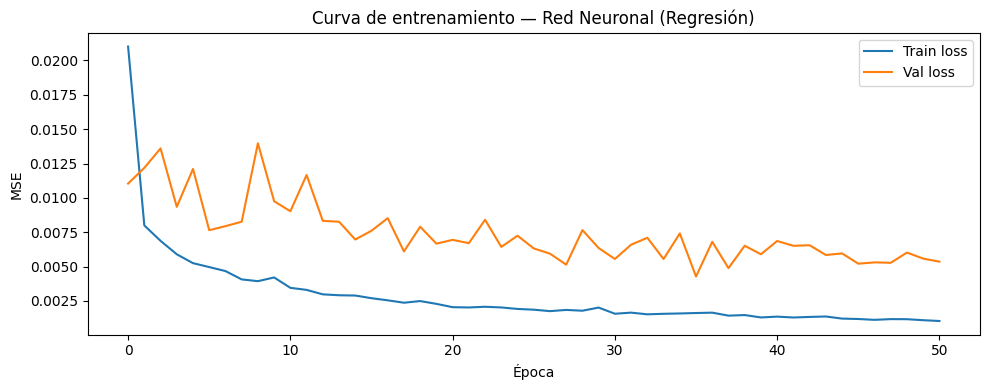

Épocas entrenadas: 51


In [ ]:
hist_df = pd.DataFrame(history.history)

plt.figure(figsize=(10, 4))
plt.plot(hist_df['loss'], label='Train loss')
plt.plot(hist_df['val_loss'], label='Val loss')
plt.xlabel('Época')
plt.ylabel('MSE')
plt.title('Curva de entrenamiento — Red Neuronal (Regresión)')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Épocas entrenadas: {len(hist_df)}")

In [ ]:
y_pred_nn = model_nn.predict(X_test).flatten()
rmse_nn = mean_squared_error(y_test, y_pred_nn) ** 0.5
print(f"RMSE Red Neuronal: {rmse_nn:.4f}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
RMSE Red Neuronal: 0.0571


In [ ]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Random Forest
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=2,
    random_state=SEED,
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
rmse_rf = mean_squared_error(y_test, y_pred_rf) ** 0.5
print(f"RMSE Random Forest:       {rmse_rf:.4f}")

# Gradient Boosting
gb = GradientBoostingRegressor(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    random_state=SEED
)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
rmse_gb = mean_squared_error(y_test, y_pred_gb) ** 0.5
print(f"RMSE Gradient Boosting:   {rmse_gb:.4f}")

RMSE Random Forest:       0.0329
RMSE Gradient Boosting:   0.0298


              Modelo     RMSE
   Gradient Boosting 0.029791
       Random Forest 0.032868
Red Neuronal (Keras) 0.057103


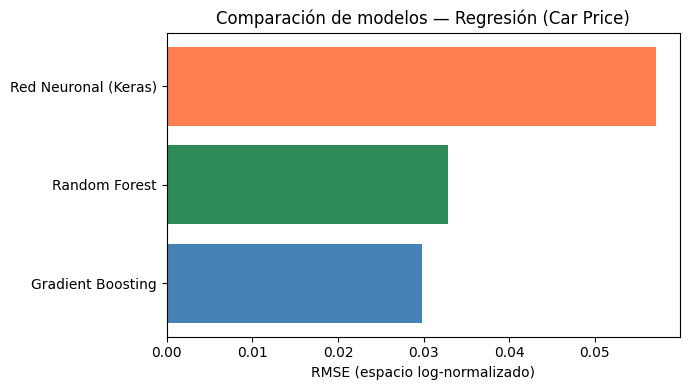

In [ ]:
#Comparación de regresión
resultados_reg = pd.DataFrame({
    'Modelo': ['Red Neuronal (Keras)', 'Random Forest', 'Gradient Boosting'],
    'RMSE': [rmse_nn, rmse_rf, rmse_gb]
}).sort_values('RMSE')

print(resultados_reg.to_string(index=False))

plt.figure(figsize=(7, 4))
plt.barh(resultados_reg['Modelo'], resultados_reg['RMSE'], color=['steelblue', 'seagreen', 'coral'])
plt.xlabel('RMSE (espacio log-normalizado)')
plt.title('Comparación de modelos — Regresión (Car Price)')
plt.tight_layout()
plt.show()

##Optimización de hiperparámetros

In [ ]:
#Optimización de hiperparpametros

rf = RandomForestRegressor(random_state=SEED, n_jobs=-1)

param_dist_rf = {
    'n_estimators': randint(100, 400),
    'max_depth': [None, 10, 15, 20],
    'min_samples_leaf': randint(1, 5),
    'max_features': ['sqrt', 'log2', None]
}

random_rf = RandomizedSearchCV(
    rf,
    param_distributions=param_dist_rf,
    n_iter=10,
    cv=3,
    scoring='neg_root_mean_squared_error',
    random_state=SEED,
    n_jobs=-1,
    verbose=1
)

random_rf.fit(X_train, y_train)

best_rf = random_rf.best_estimator_

Fitting 3 folds for each of 10 candidates, totalling 30 fits


In [ ]:
print(random_rf.best_params_)
print(random_rf.best_score_)

{'max_depth': 20, 'max_features': None, 'min_samples_leaf': 2, 'n_estimators': 274}
-0.039018546476992134


In [ ]:
best_rf = random_rf.best_estimator_
# Predicción modelo optimizado
y_pred_rf_tuned = best_rf.predict(X_test)

rmse_rf_tuned = mean_squared_error(y_test, y_pred_rf_tuned) ** 0.5

print("RMSE Random Forest original:", rmse_rf)
print("RMSE Random Forest optimizado:", rmse_rf_tuned)

RMSE Random Forest original: 0.03286751825795275
RMSE Random Forest optimizado: 0.032914325810646135


In [ ]:
gb = GradientBoostingRegressor(random_state=SEED)

param_dist_gb = {
    'n_estimators': randint(100, 400),
    'learning_rate': uniform(0.01, 0.09),
    'max_depth': randint(2, 6),
    'min_samples_leaf': randint(1, 5)
}

random_gb = RandomizedSearchCV(
    gb,
    param_distributions=param_dist_gb,
    n_iter=10,
    cv=3,
    scoring='neg_root_mean_squared_error',
    random_state=SEED,
    n_jobs=-1,
    verbose=1
)

random_gb.fit(X_train, y_train)

best_gb = random_gb.best_estimator_

In [ ]:
#optimización de hiperparámetros
from scipy.stats import uniform

gb = GradientBoostingRegressor(random_state=SEED)

param_dist_gb = {
    'n_estimators': randint(100, 400),
    'learning_rate': uniform(0.01, 0.09),   # valores aprox entre 0.01 y 0.10
    'max_depth': randint(2, 6),
    'min_samples_leaf': randint(1, 5)
}

random_gb = RandomizedSearchCV(
    estimator=gb,
    param_distributions=param_dist_gb,
    n_iter=10,
    cv=3,
    scoring='neg_root_mean_squared_error',
    random_state=SEED,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

random_gb.fit(X_train, y_train)

best_gb = random_gb.best_estimator_

print("\nMejores hiperparámetros encontrados:")
print(random_gb.best_params_)

print("\nMejor RMSE promedio en validación cruzada:")
print(-random_gb.best_score_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits

Mejores hiperparámetros encontrados:
{'learning_rate': np.float64(0.040033775002511963), 'max_depth': 5, 'min_samples_leaf': 4, 'n_estimators': 230}

Mejor RMSE promedio en validación cruzada:
0.0371680334476081


In [ ]:
best_gb = random_gb.best_estimator_

y_pred_gb_tuned = best_gb.predict(X_test)
rmse_gb_tuned = mean_squared_error(y_test, y_pred_gb_tuned) ** 0.5

print("RMSE Gradient Boosting original:", rmse_gb)
print("RMSE Gradient Boosting optimizado:", rmse_gb_tuned)
print("Mejores params:", random_gb.best_params_)

RMSE Gradient Boosting original: 0.02979092236214915
RMSE Gradient Boosting optimizado: 0.030019277486368044
Mejores params: {'learning_rate': np.float64(0.040033775002511963), 'max_depth': 5, 'min_samples_leaf': 4, 'n_estimators': 230}


# Dataset 2 - Clasificación

## Lectura y tratamiento de datos

In [ ]:
df_credit = pd.read_csv("UCI_Credit_Card.csv")
print(df_credit.shape)
df_credit.head()

(30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [ ]:
# EDA — balance de clases
print("Balance del target:")
print(df_credit['default.payment.next.month'].value_counts())
print(f"\nRatio de default: {df_credit['default.payment.next.month'].mean():.1%}")

Balance del target:
default.payment.next.month
0    23364
1     6636
Name: count, dtype: int64

Ratio de default: 22.1%


In [ ]:
# EDA — variables categóricas con valores no documentados
for col in ['EDUCATION', 'MARRIAGE']:
    print(f"\n{col}:\n{df_credit[col].value_counts().sort_index()}")


EDUCATION:
EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64

MARRIAGE:
MARRIAGE
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64


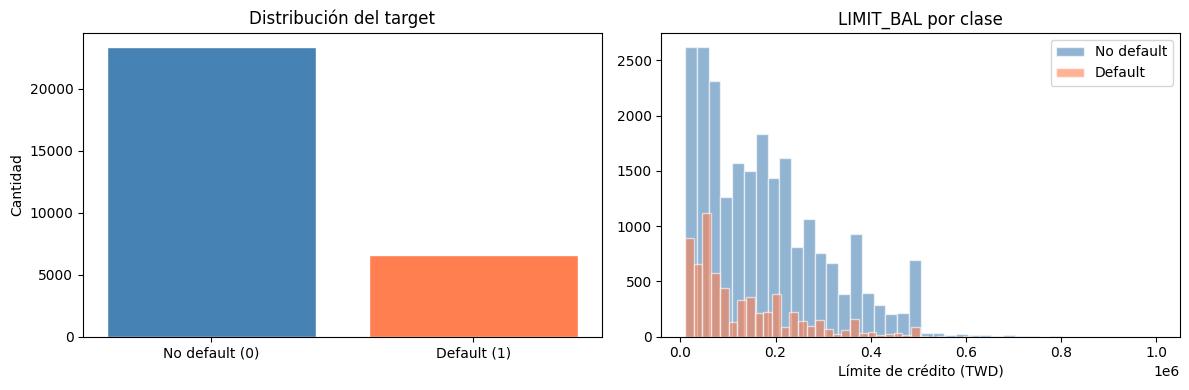

In [ ]:
# Visualización desbalanceo
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribución del target
axes[0].bar(['No default (0)', 'Default (1)'],
            df_credit['default.payment.next.month'].value_counts().sort_index(),
            color=['steelblue', 'coral'], edgecolor='white')
axes[0].set_title('Distribución del target')
axes[0].set_ylabel('Cantidad')

# Distribución de LIMIT_BAL por target
for val, color, label in [(0, 'steelblue', 'No default'), (1, 'coral', 'Default')]:
    subset = df_credit[df_credit['default.payment.next.month'] == val]['LIMIT_BAL']
    axes[1].hist(subset, bins=40, alpha=0.6, color=color, label=label, edgecolor='white')
axes[1].set_title('LIMIT_BAL por clase')
axes[1].set_xlabel('Límite de crédito (TWD)')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
df = df_credit.copy()

# 1. Drop ID — identificador sin valor predictivo
df.drop(columns=['ID'], inplace=True)

# 2. Limpiar categorías no documentadas en el paper original
#    EDUCATION: valores 0, 5, 6 no están definidos → agrupamos como 4 (Other)
df['EDUCATION'] = df['EDUCATION'].apply(lambda x: x if x in [1, 2, 3, 4] else 4)

#    MARRIAGE: valor 0 no documentado → agrupamos como 3 (Other)
df['MARRIAGE'] = df['MARRIAGE'].apply(lambda x: x if x in [1, 2, 3] else 3)

# 3. Separar features y target ANTES de normalizar
#    (no normalizamos el target binario)
y_credit = df['default.payment.next.month']
X_credit = df.drop(columns=['default.payment.next.month'])

# 4. Normalización min-max de features
X_credit = (X_credit - X_credit.min()) / (X_credit.max() - X_credit.min())

print(f"Shape X: {X_credit.shape}")
print(f"Nulls: {X_credit.isnull().sum().sum()}")
X_credit.head()

Shape X: (30000, 23)
Nulls: 0


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
0,0.010101,1.0,0.333333,0.0,0.051724,0.4,0.4,0.1,0.1,0.0,...,0.086723,0.160138,0.080648,0.260979,0.000000,0.000409,0.000000,0.000000,0.000000,0.000000
1,0.111111,1.0,0.333333,0.5,0.086207,0.1,0.4,0.2,0.2,0.2,...,0.087817,0.163220,0.084074,0.263485,0.000000,0.000594,0.001116,0.001610,0.000000,0.003783
2,0.080808,1.0,0.333333,0.5,0.224138,0.2,0.2,0.2,0.2,0.2,...,0.093789,0.173637,0.095470,0.272928,0.001738,0.000891,0.001116,0.001610,0.002345,0.009458
3,0.040404,1.0,0.333333,0.0,0.275862,0.2,0.2,0.2,0.2,0.2,...,0.113407,0.186809,0.109363,0.283685,0.002290,0.001199,0.001339,0.001771,0.002506,0.001892
4,0.040404,0.0,0.333333,0.0,0.620690,0.1,0.2,0.1,0.2,0.2,...,0.106020,0.179863,0.099633,0.275681,0.002290,0.021779,0.011160,0.014493,0.001615,0.001284


##Modelado

In [ ]:
# Split estratificado en train y test
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_credit, y_credit,
    test_size=0.2,
    random_state=SEED,
    stratify=y_credit
)

print(f"X_train: {X_train_c.shape} | X_test: {X_test_c.shape}")
print(f"Default en train: {y_train_c.mean():.1%} | en test: {y_test_c.mean():.1%}")

X_train: (24000, 23) | X_test: (6000, 23)
Default en train: 22.1% | en test: 22.1%


In [ ]:
from sklearn.metrics import f1_score, roc_auc_score, classification_report

keras.utils.set_random_seed(SEED)

model_nn_c = keras.Sequential([
    keras.layers.Input(shape=(X_train_c.shape[1],)),

    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.3),

    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.2),

    keras.layers.Dense(32, activation='relu'),

    # Salida — sigmoid para clasificación binaria
    keras.layers.Dense(1, activation='sigmoid')
])

model_nn_c.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)

model_nn_c.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │         3,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,441 (52.50 KB)

 Trainable params: 13,441 (52.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop_c = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True
)

history_c = model_nn_c.fit(
    X_train_c, y_train_c,
    epochs=100,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop_c],
    verbose=1
)

Epoch 1/100
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7845 - auc: 0.6540 - loss: 0.5010 - val_accuracy: 0.8021 - val_auc: 0.7239 - val_loss: 0.4707
Epoch 2/100
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8102 - auc: 0.7198 - loss: 0.4596 - val_accuracy: 0.8098 - val_auc: 0.7361 - val_loss: 0.4629
Epoch 3/100
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8154 - auc: 0.7313 - loss: 0.4505 - val_accuracy: 0.8104 - val_auc: 0.7426 - val_loss: 0.4588
Epoch 4/100
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8164 - auc: 0.7361 - loss: 0.4474 - val_accuracy: 0.8119 - val_auc: 0.7487 - val_loss: 0.4554
Epoch 5/100
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8172 - auc: 0.7457 - loss: 0.4432 - val_accuracy: 0.8112 - val_auc: 0.7504 - val_loss: 0.4547
Epoch 6/100
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8173 - auc: 0.7458 - loss: 0.4427 - val_accuracy: 0.8115 - val_auc: 0.7542 - val_loss: 0.4530
Epoch 7/100
300/300 ━━━━━━━━━━━━━━

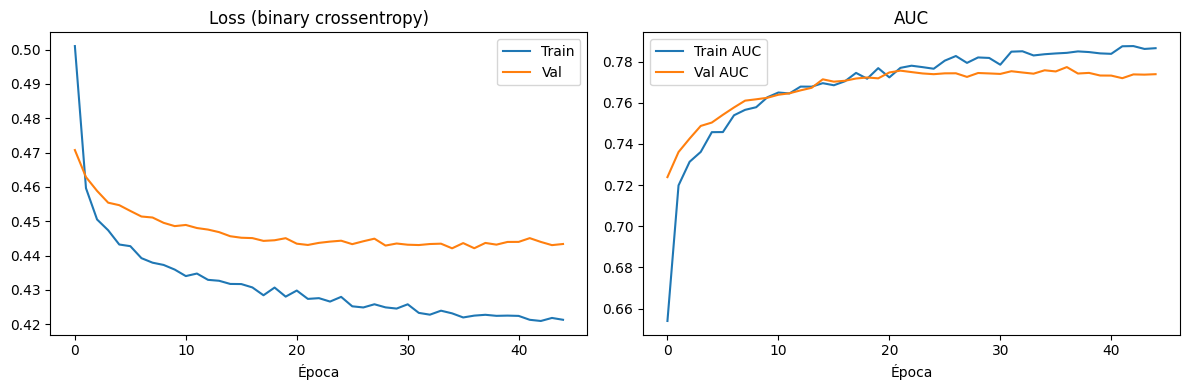

Épocas entrenadas: 45


In [ ]:
# Curva de entrenamiento
hist_c = pd.DataFrame(history_c.history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(hist_c['loss'], label='Train')
axes[0].plot(hist_c['val_loss'], label='Val')
axes[0].set_title('Loss (binary crossentropy)')
axes[0].set_xlabel('Época')
axes[0].legend()

axes[1].plot(hist_c['auc'], label='Train AUC')
axes[1].plot(hist_c['val_auc'], label='Val AUC')
axes[1].set_title('AUC')
axes[1].set_xlabel('Época')
axes[1].legend()

plt.tight_layout()
plt.show()
print(f"Épocas entrenadas: {len(hist_c)}")

In [ ]:
# Evaluación
y_pred_nn_prob = model_nn_c.predict(X_test_c).flatten()
y_pred_nn_c = (y_pred_nn_prob >= 0.5).astype(int)

f1_nn_c  = f1_score(y_test_c, y_pred_nn_c)
auc_nn_c = roc_auc_score(y_test_c, y_pred_nn_prob)

print(f"F1-score Red Neuronal: {f1_nn_c:.4f}")
print(f"AUC-ROC  Red Neuronal: {auc_nn_c:.4f}")
print("\nReporte completo:")
print(classification_report(y_test_c, y_pred_nn_c, target_names=['No default', 'Default']))

188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
F1-score Red Neuronal: 0.4708
AUC-ROC  Red Neuronal: 0.7631

Reporte completo:
              precision    recall  f1-score   support

  No default       0.84      0.94      0.89      4673
     Default       0.65      0.37      0.47      1327

    accuracy                           0.82      6000
   macro avg       0.75      0.66      0.68      6000
weighted avg       0.80      0.82      0.80      6000



In [ ]:
# Random Forest con class_weight='balanced' para compensar desbalanceo
rf_c = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=SEED,
    n_jobs=-1
)
rf_c.fit(X_train_c, y_train_c)
y_pred_rf_c      = rf_c.predict(X_test_c)
y_pred_rf_c_prob = rf_c.predict_proba(X_test_c)[:, 1]
f1_rf_c  = f1_score(y_test_c, y_pred_rf_c)
auc_rf_c = roc_auc_score(y_test_c, y_pred_rf_c_prob)
print(f"Random Forest     — F1: {f1_rf_c:.4f} | AUC: {auc_rf_c:.4f}")

# Gradient Boosting
gb_c = GradientBoostingClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=SEED
)
gb_c.fit(X_train_c, y_train_c)
y_pred_gb_c      = gb_c.predict(X_test_c)
y_pred_gb_c_prob = gb_c.predict_proba(X_test_c)[:, 1]
f1_gb_c  = f1_score(y_test_c, y_pred_gb_c)
auc_gb_c = roc_auc_score(y_test_c, y_pred_gb_c_prob)
print(f"Gradient Boosting — F1: {f1_gb_c:.4f} | AUC: {auc_gb_c:.4f}")

Random Forest     — F1: 0.5388 | AUC: 0.7720
Gradient Boosting — F1: 0.4650 | AUC: 0.7795


## Optimización de hiperparámetros

In [ ]:
#optimización de hiperparámetros

param_dist_rf_c = {
    'n_estimators': randint(100, 400),
    'max_depth': [None, 10, 15, 20],
    'min_samples_leaf': randint(1, 5),
    'max_features': ['sqrt', 'log2', None]
}

random_rf_c = RandomizedSearchCV(
    RandomForestClassifier(
        random_state=SEED,
        class_weight='balanced',
        n_jobs=-1
    ),
    param_distributions=param_dist_rf_c,
    n_iter=5,
    cv=3,
    scoring='f1',
    random_state=SEED,
    n_jobs=-1,
    verbose=1
)

random_rf_c.fit(X_train_c, y_train_c)

best_rf_c = random_rf_c.best_estimator_

y_pred_rf_tuned = best_rf_c.predict(X_test_c)
y_pred_rf_tuned_prob = best_rf_c.predict_proba(X_test_c)[:, 1]
f1_rf_tuned = f1_score(y_test_c, y_pred_rf_tuned)
auc_rf_tuned = roc_auc_score(y_test_c, y_pred_rf_tuned_prob)

print("F1 RF optimizado:", f1_rf_tuned)
print("Mejores params:", random_rf_c.best_params_)

Fitting 3 folds for each of 5 candidates, totalling 15 fits
F1 RF optimizado: 0.5350877192982456
Mejores params: {'max_depth': 10, 'max_features': None, 'min_samples_leaf': 3, 'n_estimators': 187}


In [ ]:
print("AUC RF optimizado:", auc_rf_tuned)

AUC RF optimizado: 0.7724183451536033


In [ ]:
param_dist_gb_c = {
    'n_estimators': randint(100, 400),
    'learning_rate': uniform(0.01, 0.09),
    'max_depth': randint(2, 6),
    'min_samples_leaf': randint(1, 5)
}

random_gb_c = RandomizedSearchCV(
    gb_c,
    param_distributions=param_dist_gb_c,
    n_iter=5,
    cv=3,
    scoring='f1',
    random_state=SEED,
    n_jobs=-1,
    verbose=1
)

random_gb_c.fit(X_train_c, y_train_c)

best_gb_c = random_gb_c.best_estimator_

y_pred_gb_tuned = best_gb_c.predict(X_test_c)
y_pred_gb_tuned_prob = best_gb_c.predict_proba(X_test_c)[:, 1]
f1_gb_tuned = f1_score(y_test_c, y_pred_gb_tuned)
auc_gb_tuned = roc_auc_score(y_test_c, y_pred_gb_tuned_prob)

print("F1 GB optimizado:", f1_gb_tuned)
print("AUC GB optimizado:", auc_gb_tuned)
print("Mejores params:", random_gb_c.best_params_)

Fitting 3 folds for each of 5 candidates, totalling 15 fits
F1 GB optimizado: 0.4678362573099415
AUC GB optimizado: 0.7779764979307606
Mejores params: {'learning_rate': np.float64(0.08017219002454923), 'max_depth': 2, 'min_samples_leaf': 3, 'n_estimators': 221}


In [ ]:
resultados_clf = pd.DataFrame({
    'Modelo': ['Red Neuronal (Keras)', 'Random Forest optimizado', 'Gradient Boosting optimizado'],
    'F1': [f1_nn_c, f1_rf_tuned, f1_gb_tuned],
    'AUC': [auc_nn_c, auc_rf_tuned, auc_gb_tuned]
}).sort_values('F1', ascending=False)

print(resultados_clf.to_string(index=False))

                      Modelo       F1      AUC
    Random Forest optimizado 0.535088 0.772418
        Red Neuronal (Keras) 0.470815 0.763071
Gradient Boosting optimizado 0.467836 0.777976


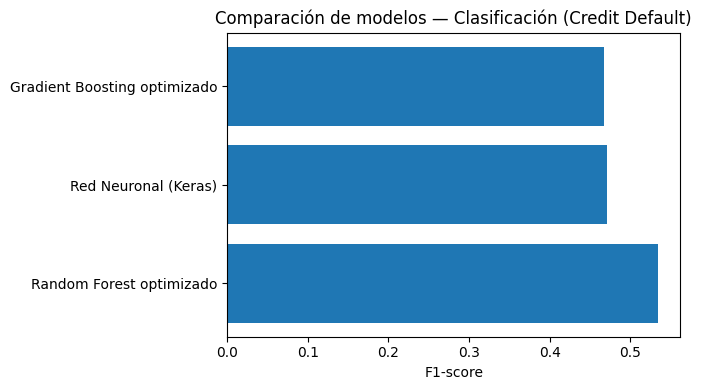

In [ ]:
plt.figure(figsize=(7,4))
plt.barh(resultados_clf['Modelo'], resultados_clf['F1'])
plt.xlabel('F1-score')
plt.title('Comparación de modelos — Clasificación (Credit Default)')
plt.tight_layout()
plt.show()

In [ ]:
# RANDOM FOREST ORIGINAL
y_pred_rf_original = rf_c.predict(X_test_c)
y_prob_rf_original = rf_c.predict_proba(X_test_c)[:, 1]

f1_rf_original = f1_score(y_test_c, y_pred_rf_original)
auc_rf_original = roc_auc_score(y_test_c, y_prob_rf_original)

# RANDOM FOREST OPTIMIZADO
y_pred_rf_tuned = best_rf_c.predict(X_test_c)
y_prob_rf_tuned = best_rf_c.predict_proba(X_test_c)[:, 1]

f1_rf_tuned = f1_score(y_test_c, y_pred_rf_tuned)
auc_rf_tuned = roc_auc_score(y_test_c, y_prob_rf_tuned)

# GRADIENT BOOSTING ORIGINAL
y_pred_gb_original = gb_c.predict(X_test_c)
y_prob_gb_original = gb_c.predict_proba(X_test_c)[:, 1]

f1_gb_original = f1_score(y_test_c, y_pred_gb_original)
auc_gb_original = roc_auc_score(y_test_c, y_prob_gb_original)

# GRADIENT BOOSTING OPTIMIZADO
y_pred_gb_tuned = best_gb_c.predict(X_test_c)
y_prob_gb_tuned = best_gb_c.predict_proba(X_test_c)[:, 1]

f1_gb_tuned = f1_score(y_test_c, y_pred_gb_tuned)
auc_gb_tuned = roc_auc_score(y_test_c, y_prob_gb_tuned)

# TABLA COMPARATIVA
comparacion = pd.DataFrame({
    'Modelo': [
        'RF original',
        'RF optimizado',
        'GB original',
        'GB optimizado'
    ],
    'F1': [
        f1_rf_original,
        f1_rf_tuned,
        f1_gb_original,
        f1_gb_tuned
    ],
    'AUC': [
        auc_rf_original,
        auc_rf_tuned,
        auc_gb_original,
        auc_gb_tuned
    ]
})

print("\nComparación modelos clasificación:")
print(comparacion.to_string(index=False))


Comparación modelos clasificación:
       Modelo       F1      AUC
  RF original 0.538837 0.772004
RF optimizado 0.535088 0.772418
  GB original 0.465002 0.779454
GB optimizado 0.467836 0.777976
